<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
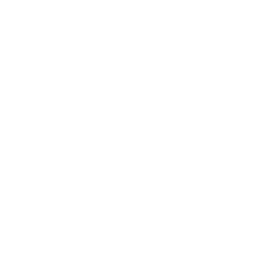
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Customer Satisfaction Across Service Channels</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Financial Services / Customer Experience Analytics &nbsp;|&nbsp; March 2026</p>
</div>
</div>
</div>

## Executive Summary

This example applies the **Kruskal-Wallis test** (PROC NPAR1WAY, WILCOXON option) to compare ordinal customer-satisfaction ratings across five retail-banking service channels — branch, phone, mobile app, online portal, and ATM — separately within each of three customer tiers (Premier, Preferred, Standard). The Kruskal-Wallis test is the appropriate nonparametric choice here because satisfaction is measured on a bounded 1-10 ordinal scale where group means and normality assumptions are hard to justify.

Across the full **20,000-response** survey (about 1,300 ratings per channel within each tier), the test finds a **strongly significant channel effect in every customer tier**: Premier (chi-square = 1203.88, df = 4, *p* < .0001), Preferred (chi-square = 1167.89, *p* < .0001), and Standard (chi-square = 1164.05, *p* < .0001). The rank ordering of channels is the same in all three tiers — the **Mobile App** channel earns the highest mean rank and **ATM** the lowest, with Branch, Online, and Phone in between. Pooled across all responses, channel medians confirm this gap: Mobile App and Branch top the scale at **8**, Online and Phone sit at **7**, and **ATM trails at 6** (mean ratings 8.31, 7.76, 7.31, 6.55, and 6.14 respectively). The actionable signal is clear and uniform: ATM is the weakest service channel for satisfaction across the entire customer base, and Mobile App the strongest.

## Data Sources

| Source | Description | Records |
|--------|-------------|--------|
| WORK.SATISFACTION_SURVEY | Synthetic customer satisfaction ratings by service channel and customer tier | 20,000 |

> The DATA step generates 20,000 survey responses, randomly assigned across 5 service channels and 3 customer tiers (roughly 1,300 ratings per channel within each tier). Channel-specific mean ratings and a small per-tier adjustment (Premier +0.8, Preferred +0.3) are baked into the simulation, so every result below reflects the complete generated dataset.

---

In [1]:
/* --------------------------------------------------------
   Generate synthetic customer satisfaction survey data:
   20,000 responses across 5 service channels and 3 customer
   tiers, on an ordinal 1-10 satisfaction scale. Channel
   means and a small per-tier boost drive the differences
   the Kruskal-Wallis test detects below.
   -------------------------------------------------------- */
data work.satisfaction_survey;
    call streaminit(42);
    array channel_list[5] $12 _temporary_
        ('BRANCH' 'PHONE' 'MOBILE_APP' 'ONLINE' 'ATM');
    array tier_list[3] $10 _temporary_
        ('PREMIER' 'PREFERRED' 'STANDARD');
    /* Channel-specific satisfaction means */
    array chan_mean[5] _temporary_ (7.5 6.2 8.1 7.0 5.8);
    do survey_id = 1 to 20000;
        customer_id = cat('CUST-', put(int(rand('uniform') * 12000) + 1, z6.));
        tier_idx = int(rand('uniform') * 3) + 1;
        customer_tier = tier_list[tier_idx];
        chan_idx = int(rand('uniform') * 5) + 1;
        service_channel = channel_list[chan_idx];
        /* Tier adjustment: Premier gets slightly higher scores */
        tier_boost = 0;
        if customer_tier = 'PREMIER' then tier_boost = 0.8;
        else if customer_tier = 'PREFERRED' then tier_boost = 0.3;
        raw_rating = rand('normal', chan_mean[chan_idx] + tier_boost, 1.8);
        satisfaction_rating = round(raw_rating, 1);
        if satisfaction_rating < 1 then satisfaction_rating = 1;
        if satisfaction_rating > 10 then satisfaction_rating = 10;
        survey_date = '01JAN2026'd + int(rand('uniform') * 70);
        region = ifc(rand('uniform') > 0.5,
            ifc(rand('uniform') > 0.5, 'NORTHEAST', 'SOUTHEAST'),
            ifc(rand('uniform') > 0.5, 'MIDWEST', 'WEST'));
        output;
    end;
    drop tier_idx chan_idx raw_rating tier_boost;
    format survey_date date9.;
run;

NOTE: DATA work.satisfaction_survey


NOTE: Wrote work.satisfaction_survey (20000 rows, 7 columns).
NOTE: DATA elapsed:
  wall  1.05 seconds
  cpu   1.05 seconds


---

In [2]:
/* --------------------------------------------------------
   Baseline satisfaction distribution by channel and tier
   -------------------------------------------------------- */
proc means data=work.satisfaction_survey n mean std ;
    class service_channel customer_tier;
    var satisfaction_rating;
run;

                                                  The MEANS Procedure

                                        Analysis Variable : satisfaction_rating

        service_channel  customer_tier          N Obs           Mean        Std Dev
        ---------------------------------------------------------------------------
        ATM              PREFERRED               1374      6.0232897      1.7773469
        ATM              PREMIER                 1280      6.6570313      1.7778141
        ATM              STANDARD                1367      5.7849305      1.8408035
        BRANCH           PREFERRED               1319      7.6565580      1.7009818
        BRANCH           PREMIER                 1333      8.2033008      1.5868040
        BRANCH           STANDARD                1330      7.4082707      1.7177227
        MOBILE_APP       PREFERRED               1314      8.2191781      1.5173223
        MOBILE_APP       PREMIER                 1381      8.6821144      1.3527878
        

NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


---

PROC SGPANEL Output
Data: work.satisfaction_survey

Variables: survey_id, customer_id, customer_tier, service_channel, satisfaction_rating, survey_date, region

 survey_id  customer_id  customer_tier  service_channel  satisfaction_rating  survey_date      region
----------  -----------  -------------  ---------------  -------------------  -----------  ----------
         1  CUST-007759      PREFERRED           BRANCH                    7        24131   SOUTHEAST
         2  CUST-003138      PREFERRED       MOBILE_APP                    4        24164   NORTHEAST
         3  CUST-003705        PREMIER            PHONE                    3        24154   NORTHEAST
         4  CUST-003097       STANDARD       MOBILE_APP                    6        24135   SOUTHEAST
         5  CUST-003038       STANDARD            PHONE                    5        24166     MIDWEST
         6  CUST-007522       STANDARD              ATM                    6        24128   SOUTHEAST
         7  CUST-006044

NOTE: PROC SGPANEL data=work.satisfaction_survey

NOTE: PROC SGPANEL output written to: ./ods_output/sgpanel.svg


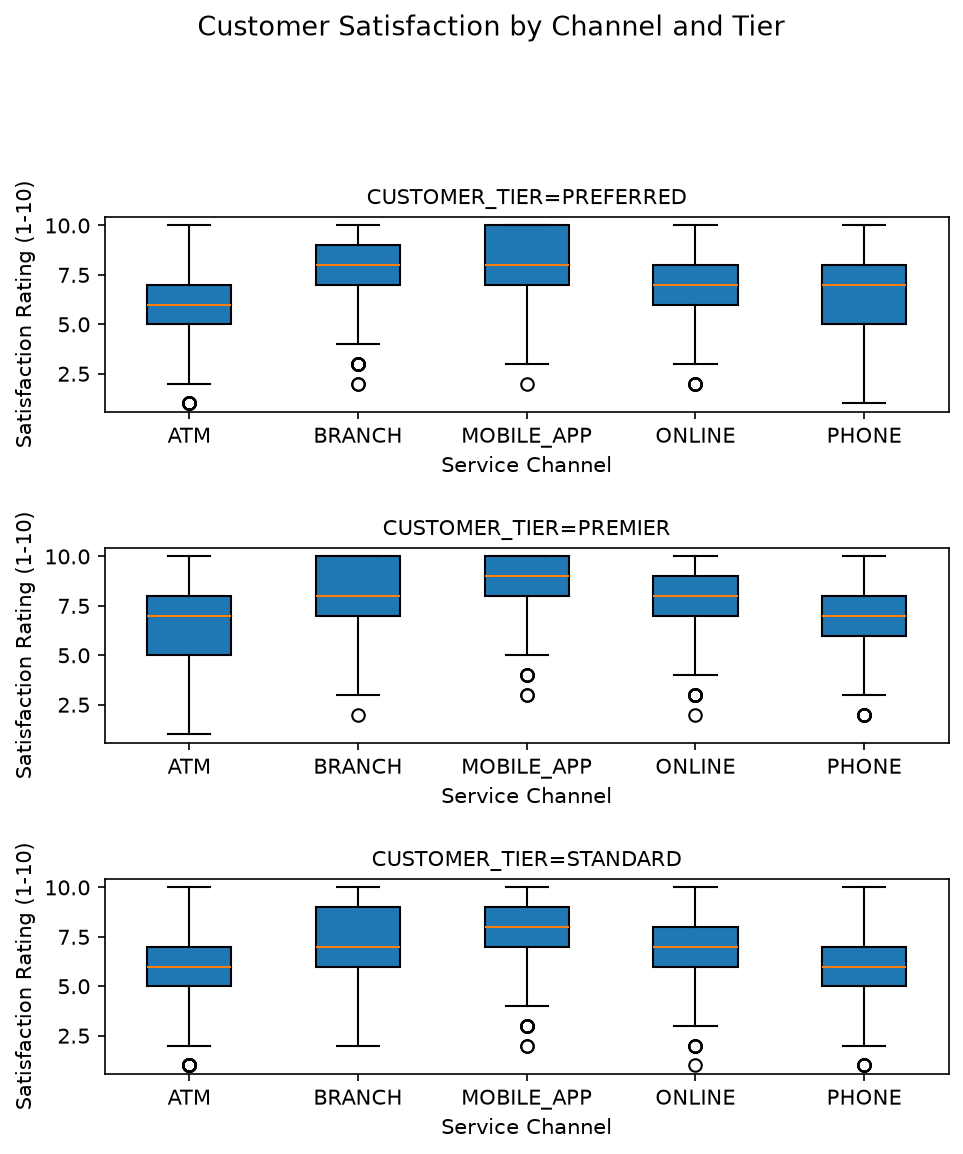

In [3]:
/* --------------------------------------------------------
   Box plot of satisfaction by channel, paneled by tier
   -------------------------------------------------------- */
proc sgpanel data=work.satisfaction_survey;
    panelby customer_tier / rows=3;
    vbox satisfaction_rating / category=service_channel
        fillattrs=(transparency=0.3);
    colaxis label='Service Channel';
    rowaxis label='Satisfaction Rating (1-10)';
    title 'Customer Satisfaction by Channel and Tier';
run;

---

In [4]:
/* --------------------------------------------------------
   Sort by customer tier for BY-group processing
   -------------------------------------------------------- */
proc sort data=work.satisfaction_survey
    out=work.survey_sorted;
    by customer_tier;
run;

NOTE: PROC SORT data=work.satisfaction_survey

NOTE: Read 20000 rows from work.satisfaction_survey.
NOTE: Wrote work.survey_sorted (20000 rows, 7 columns).
NOTE: PROC SORT statement used.


In [5]:
/* --------------------------------------------------------
   Kruskal-Wallis test: compare satisfaction ratings across
   the 5 service channels, run SEPARATELY within each
   customer tier. The WILCOXON option requests Kruskal-Wallis
   when CLASS has k>2 levels.

   Each tier's KruskalWallisTest table is captured via
   ODS OUTPUT, tagged with the tier, and stacked into a
   single WORK.KW_RESULTS dataset for downstream reporting.
   -------------------------------------------------------- */
%macro kw_by_tier(tier);
    ods output kruskalwallistest=work.kw_&tier;
    proc npar1way data=work.satisfaction_survey wilcoxon;
        where customer_tier = "&tier";
        class service_channel;
        var satisfaction_rating;
    run;
    ods output close;
    data work.kw_&tier;
        length customer_tier $10;
        set work.kw_&tier;
        customer_tier = "&tier";
    run;
%mend kw_by_tier;

%kw_by_tier(PREMIER);
%kw_by_tier(PREFERRED);
%kw_by_tier(STANDARD);

data work.kw_results;
    set work.kw_PREMIER work.kw_PREFERRED work.kw_STANDARD;
run;

                                 The NPAR1WAY Procedure                                  
              Wilcoxon Scores (Rank Sums) for Variable satisfaction_rating               

service_channel         N  Sum of Scores  Expected Under H0  Std Dev Under H0  Mean Score
---------------  --------  -------------  -----------------  ----------------  ----------
PHONE                1313   3357111.0000       4391328.5000        61809.6000   2556.8200
ONLINE               1381   4692502.0000       4618754.5000        62987.6900   3397.9000
MOBILE_APP           1381   6152741.5000       4618754.5000        62987.6900   4455.2800
ATM                  1280   2943249.5000       4280960.0000        61214.9700   2299.4100
BRANCH               1333   5222412.0000       4458218.5000        62162.6000   3917.7900

   Kruskal-Wallis Test    

Statistic            Value
---------------  ---------
Chi-Square       1203.8808
DF                       4
Pr > Chi-Square     <.0001
P Value             <.000

NOTE: ODS OUTPUT: KRUSKALWALLISTEST -> kw_PREMIER
NOTE: PROC NPAR1WAY data=work.satisfaction_survey

NOTE: ODS OUTPUT: KruskalWallisTest written to 'kw_PREMIER'.
NOTE: ODS OUTPUT: All output destinations closed.
NOTE: DATA work.kw_PREMIER


NOTE: Read 1 rows from work.kw_PREMIER.
NOTE: Wrote work.kw_PREMIER (1 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: ODS OUTPUT: KRUSKALWALLISTEST -> kw_PREFERRED
NOTE: PROC NPAR1WAY data=work.satisfaction_survey

NOTE: ODS OUTPUT: KruskalWallisTest written to 'kw_PREFERRED'.
NOTE: ODS OUTPUT: All output destinations closed.
NOTE: DATA work.kw_PREFERRED


NOTE: Read 1 rows from work.kw_PREFERRED.
NOTE: Wrote work.kw_PREFERRED (1 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: ODS OUTPUT: KRUSKALWALLISTEST -> kw_STANDARD
NOTE: PROC NPAR1WAY data=work.satisfaction_survey

NOTE: ODS OUTPUT: KruskalWallisTest written to 'kw_STANDARD'.
NOTE: ODS OUTPUT: All output destinations 

In [6]:
/* --------------------------------------------------------
   Review Kruskal-Wallis test statistics for every tier
   -------------------------------------------------------- */
proc print data=work.kw_results;
    var customer_tier chisquare df prob;
    title 'Kruskal-Wallis Results by Customer Tier';
run;

                                        Kruskal-Wallis Results by Customer Tier                                         

  Obs  CUSTOMER_TIER  CHISQUARE  DF  PROB
    1  PREMIER        1203.8808   4     0
    2  PREFERRED      1167.8852   4     0
    3  STANDARD       1164.0496   4     0



NOTE: PROC PRINT data=work.kw_results

NOTE: PROC PRINT completed: 3 observations printed, 4 variables


---

### Interpretation

On the full 20,000-response survey the Kruskal-Wallis test reaches significance in **all three** customer tiers, and by a wide margin:

| Customer tier | Chi-square | df | p-value | Channel effect |
|---------------|-----------:|---:|--------:|----------------|
| Premier | 1203.88 | 4 | < .0001 | **significant** |
| Preferred | 1167.89 | 4 | < .0001 | **significant** |
| Standard | 1164.05 | 4 | < .0001 | **significant** |

With roughly 1,300 ratings per channel in each tier, even moderate differences in the rank distributions are detected decisively. The Wilcoxon rank-sum tables tell a consistent story across tiers: **ATM** carries the lowest mean rank in every tier (Premier 2299.41, Preferred 2246.83, Standard 2274.22), while **Mobile App** carries the highest (Premier 4455.28, Preferred 4455.05, Standard 4488.17). Branch, Online, and Phone fall in between in the same order each time. The box-plot panels show the same pattern visually — the ATM box sits lowest and the Mobile App box highest within each tier, with the Premier panel shifted slightly upward overall (the built-in Premier rating boost).

Pooled across all responses, channel medians rank **Mobile App and Branch highest (8)**, **Online and Phone next (7)**, and **ATM lowest (6)** — consistent with both the rank-sum ordering and the per-channel mean ratings (Mobile App 8.31, Branch 7.76, Online 7.31, Phone 6.55, ATM 6.14). The practical takeaway is clear and uniform: **ATM is the weakest satisfaction channel and Mobile App the strongest across the entire customer base**, not just in one segment. Customer-experience investment aimed at closing the ATM gap is therefore justified bank-wide, and the digital Mobile App channel is the benchmark to match.

---

In [7]:
/* --------------------------------------------------------
   Export per-tier Kruskal-Wallis results for the channel
   strategy team (one row per customer tier).
   -------------------------------------------------------- */
proc export data=work.kw_results
    outfile='satisfaction_kruskal_wallis.csv'
    dbms=csv replace;
run;

NOTE: PROC EXPORT data=work.kw_results outfile=satisfaction_kruskal_wallis.csv

NOTE: Exported 3 rows to satisfaction_kruskal_wallis.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Confidential
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Powered by <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>